<a id="innhold"></a>

# GNSS Multipath Analysis – bruk av biblioteket direkte

Denne notebooken viser hvordan `gnssmultipath` kan brukes som et vanlig Python-bibliotek, uten å kjøre
hele multipath-analysen: lese RINEX-observasjoner, interpolere satellittkoordinater fra både
kringkastede efemerider og presise baner (SP3), og til slutt visualisere resultatet.

## Innhold

1. [RINEX observasjonsfiler](#rinex-obs)
    - [1.1 Hente ut data](#hente-ut-data)
    - [1.2 Lage en pandas DataFrame](#dataframe)
2. [Interpolasjon av satellittkoordinater](#satkoord)
    - [2.1 Kringkastede efemerider (navigasjonsfiler)](#broadcast)
    - [2.2 Presise satellittkoordinater (SP3-filer)](#sp3)
3. [Diverse – polarplot](#diverse)

Cellene er ment å kjøres i rekkefølge, siden senere seksjoner gjenbruker objekter fra de tidligere.


<a id="rinex-obs"></a>

# 1. RINEX observasjonsfiler

`readRinexObs` leser observasjonsfila og returnerer et `RinexObsData`-objekt med observasjoner,
epoketider og headerinformasjon. Riktig leserutine (RINEX v2 eller v3/v4) velges automatisk ut fra
versjonsnummeret i fila.

[Tilbake til innholdsfortegnelsen](#innhold)


In [ ]:
from pathlib import Path
from gnssmultipath import readRinexObs


repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'TestData').is_dir())
rinObsFilename1 = repo_root / 'TestData' / 'ObservationFiles' / 'v3' / 'OPEC00NOR_S_20220010000_01D_30S_MO_3.04.rnx'

# Hele RinexObsData-objektet beholdes, slik at tid, header og posisjon kan gjenbrukes i seksjon 2
rinex = readRinexObs(rinObsFilename1)

# .observations gir det kodebaserte grensesnittet mot selve observasjonene
obs = rinex.observations


INFO(rinexReadObsFileHeader304): Rinex header has been read


Rinex observations are being read: 100%|██████████| (100/100)

INFO(readRinexObs304): The following GNSS systems have been read into the data: GPS, GLONASS, Galileo, Beidou
INFO(readRinexObs304): The following GPS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2W, L2W, D2W, S2W, C2X, L2X, D2X, S2X, C5X, L5X, D5X, S5X
INFO(readRinexObs304): The following GLONASS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2C, L2C, D2C, S2C, C2P, L2P, D2P, S2P
INFO(readRinexObs304): The following Galileo observation types have been registered: C1X, L1X, D1X, S1X, C5X, L5X, D5X, S5X, C7X, L7X, D7X, S7X, C8X, L8X, D8X, S8X
INFO(readRinexObs304): The following Beidou observation types have been registered: C2X, L2X, D2X, S2X, C6X, L6X, D6X, S6X, C7X, L7X, D7X, S7X
INFO(readRinexObs304): LLI have been read (if present in observation file)
INFO(readRinexObs304): SS have been read (if present in observation file)
INFO(readRinexObs304): Total processing time: 2.123550 seconds




<a id="hente-ut-data"></a>

## 1.1 Hente ut data

Eksempler på hvordan man kan hente ut data for hvert system, samt hvordan man henter enkeltsignaler,
frekvenser, bølgelengder osv.


In [ ]:
# Hent observasjoner for hver GNSS-konstellasjon
gps = obs["G"]
galileo = obs["E"]
glonass = obs["R"]
beidou = obs["C"]

# Hent ut frekvensene for de to første GPS-båndene (L1 og L2) for å kunne lage ionosfærefrie lineærkombinasjoner
f1 = gps.frequency('C1C')
f2 = gps.frequency('C2W')

# Hente ut bølgelengdene for de to første GPS-båndene (L1 og L2)
gps_lambda1 = gps.wavelength('L1C')
gps_lambda2 = gps.wavelength('L2W')


# Pseudoranges i meter, faseobservasjonene konvertert fra bølgelengder til meter
C1C = gps.get('C1C')
C2W = gps.get('C2W')
L1C = gps.get('L1C') * gps_lambda1
L2W = gps.get('L2W') * gps_lambda2


# Ionosfære-fri kodemålinger
P_IF = (f1**2 * C1C - f2**2 * C2W) / (f1**2 - f2**2)

# Ionosfære-fri faseobservasjoner
L_IF = (f1**2 * L1C - f2**2 * L2W) / (f1**2 - f2**2)



<a id="dataframe"></a>

## 1.2 Lage en pandas DataFrame med de signalene man ønsker

Lett å se på de aktuelle signalene, samt skrive til en CSV-fil om ønskelig.


### Kun GPS


In [ ]:
CODES = ['C1C', 'C2W', 'L1C', 'L2W']

# Én rad per satellitt og epoke. Raden beholdes så lenge minst én av kodene
# har en verdi; manglende enkeltsignaler blir NaN i sin egen kolonne.
# Bruk gps.to_dataframe(codes=CODES, dropna=False) for det fulle rutenettet.
df_gps = (gps.to_dataframe(codes=CODES)
           # 'sv' er nullpolstret (G01..G32) og sorterer derfor likt som PRN.
           # Ved flere systemer i samme tabell må 'system' også inn i indeksen.
           .pivot(index=['sv', 'datetime'], columns='code', values='value')[CODES]
           .reset_index()
           .rename_axis(columns=None))  # fjerner 'code' som navn på kolonneaksen

df_gps.to_csv('gps_observations.csv', index=False)
df_gps.head()


,sv,datetime,C1C,C2W,L1C,L2W
0,G01,2022-01-01 00:00:00,2.461555e+07,2.461555e+07,1.293557e+08,1.007966e+08
1,G01,2022-01-01 00:00:30,2.459352e+07,2.459353e+07,1.292399e+08,1.007064e+08
2,G01,2022-01-01 00:01:00,2.457152e+07,2.457152e+07,1.291243e+08,1.006163e+08
3,G01,2022-01-01 00:01:30,2.454952e+07,2.454953e+07,1.290087e+08,1.005262e+08
4,G01,2022-01-01 00:02:00,2.452755e+07,2.452755e+07,1.288932e+08,1.004362e+08


### Alle systemer og alle observasjonskoder i én tabell

Utelater man `systems` og `codes`, tas alle konstellasjoner og alle koder i fila med.
Kolonnesettet blir da unionen av kodene på tvers av systemene, så en kode som bare
finnes i ett system (f.eks. `C2W` for GPS) blir NaN for de øvrige.


In [ ]:
for sys_code in obs.systems:
    print(f"{obs[sys_code].system_name:9s} ({sys_code}): {obs[sys_code].codes}")

# Uten codes/systems tas alt med. 'system' må være med i indeksen, siden
# PRN-numrene gjentas på tvers av konstellasjonene.
df_alle = (obs.to_dataframe()
             .pivot(index=['system', 'sv', 'datetime'], columns='code', values='value')
             .reset_index()
             .rename_axis(columns=None))

df_alle.to_csv('alle_observasjoner.csv', index=False)
df_alle.head()



GPS       (G): ['C1C', 'L1C', 'D1C', 'S1C', 'C1P', 'L1P', 'D1P', 'S1P', 'C2W', 'L2W', 'D2W', 'S2W', 'C2X', 'L2X', 'D2X', 'S2X', 'C5X', 'L5X', 'D5X', 'S5X']
GLONASS   (R): ['C1C', 'L1C', 'D1C', 'S1C', 'C1P', 'L1P', 'D1P', 'S1P', 'C2C', 'L2C', 'D2C', 'S2C', 'C2P', 'L2P', 'D2P', 'S2P']
Galileo   (E): ['C1X', 'L1X', 'D1X', 'S1X', 'C5X', 'L5X', 'D5X', 'S5X', 'C7X', 'L7X', 'D7X', 'S7X', 'C8X', 'L8X', 'D8X', 'S8X']
BeiDou    (C): ['C2X', 'L2X', 'D2X', 'S2X', 'C6X', 'L6X', 'D6X', 'S6X', 'C7X', 'L7X', 'D7X', 'S7X']


,system,sv,datetime,C1C,C1P,C1X,C2C,C2P,C2W,C2X,...,S1P,S1X,S2C,S2P,S2W,S2X,S5X,S6X,S7X,S8X
0,C,C05,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4.019028e+07,...,NaN,NaN,NaN,NaN,NaN,36.3,NaN,35.2,35.9,NaN
1,C,C05,2022-01-01 00:00:30,NaN,NaN,NaN,NaN,NaN,NaN,4.019027e+07,...,NaN,NaN,NaN,NaN,NaN,36.4,NaN,35.5,36.5,NaN
2,C,C05,2022-01-01 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,4.019027e+07,...,NaN,NaN,NaN,NaN,NaN,36.3,NaN,35.6,35.2,NaN
3,C,C05,2022-01-01 00:01:30,NaN,NaN,NaN,NaN,NaN,NaN,4.019026e+07,...,NaN,NaN,NaN,NaN,NaN,35.9,NaN,35.4,35.9,NaN
4,C,C05,2022-01-01 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,4.019025e+07,...,NaN,NaN,NaN,NaN,NaN,36.2,NaN,35.0,35.0,NaN


<a id="satkoord"></a>

# 2. Interpolasjon av satellittkoordinater

Satellittkoordinater i ECEF kan hentes fra to kilder, og begge interpoleres til observasjonsepokene:

| Kilde | Klasse | Nøyaktighet | Kommentar |
| --- | --- | --- | --- |
| Kringkastede efemerider (RINEX nav) | `SatelliteEphemerisToECEF` | ~1–2 m | Følger med signalet, tilgjengelig i sanntid |
| Presise baner (SP3) | `PreciseSatCoords` | ~2–5 cm | Lastes ned i etterkant (f.eks. fra CDDIS) |

Begge klassene gir samme datastruktur tilbake:

```python
{'G': {'position': {'1': array([[X, Y, Z], ...]), ...},
       'azimuth':   array([n_epoker, maks_PRN + 1]),
       'elevation': array([n_epoker, maks_PRN + 1])}, ...}
```

Azimut- og elevasjonsmatrisene er indeksert på PRN-nummer i kolonneretningen, slik at de kan sendes
rett inn i plotterutinene.

[Tilbake til innholdsfortegnelsen](#innhold)


<a id="broadcast"></a>

## 2.1 Kringkastede efemerider (navigasjonsfiler)

Her leses navigasjonsfila inn med `RinexNav`, og `SatelliteEphemerisToECEF` konverterer de
kringkastede efemeridene til ECEF-koordinater og interpolerer dem til observasjonsepokene:

* GPS, Galileo og BeiDou: Kepler-elementene propageres til hver epoke (`Kepler2ECEF`).
* GLONASS: tilstandsvektoren integreres med 4. ordens Runge-Kutta (`GLOStateVec2ECEF`).


In [ ]:
import numpy as np
from gnssmultipath import RinexNav, SatelliteEphemerisToECEF

rinNavFilename = repo_root / 'TestData' / 'NavigationFiles' / 'v3' / 'BRDC00IGS_R_20220010000_01D_MN.rnx'

# Tilnærmet mottakerposisjon (ECEF) fra headeren i observasjonsfila
x_rec, y_rec, z_rec = rinex.approxPosition.flatten().astype(float)
print(f"Approx. posisjon (ECEF) fra RINEX header: X={x_rec:.3f}  Y={y_rec:.3f}  Z={z_rec:.3f}")

# Navigasjonsfila kan også leses direkte hvis man kun vil se på efemeridene.
# data_rate er ønsket oppdateringsrate for efemeridene i minutter.
navdata = RinexNav.read_nav(str(rinNavFilename))
navdata.gps.head()


INFO(rinexReadObsFileHeader304): Rinex header has been read


Rinex observations are being read: 100%|██████████| (100/100)


INFO(readRinexObs304): The following GNSS systems have been read into the data: GPS, GLONASS, Galileo, Beidou
INFO(readRinexObs304): The following GPS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2W, L2W, D2W, S2W, C2X, L2X, D2X, S2X, C5X, L5X, D5X, S5X
INFO(readRinexObs304): The following GLONASS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2C, L2C, D2C, S2C, C2P, L2P, D2P, S2P
INFO(readRinexObs304): The following Galileo observation types have been registered: C1X, L1X, D1X, S1X, C5X, L5X, D5X, S5X, C7X, L7X, D7X, S7X, C8X, L8X, D8X, S8X
INFO(readRinexObs304): The following Beidou observation types have been registered: C2X, L2X, D2X, S2X, C6X, L6X, D6X, S6X, C7X, L7X, D7X, S7X
INFO(readRinexObs304): LLI have been read (if present in observation file)
INFO(readRinexObs304): SS have been read (if present in observation file)
INFO(readRinexObs304): Total processing time: 2.297699 seconds


Approx. posisjon (ECEF) f

Rinex navigation file is being read: 100%|██████████| (100/100)


,PRN,Year,Month,Day,Hour,Minute,Second,af0,af1,af2,...,IDOT,L2_codes,GPS_week,L2P_flag,SV_accuracy,SV_health,TGD,IODC,Transmission_time,Fit_interval
0,G01,2022.0,1.0,1.0,0.0,0.0,0.0,0.000469,-1.000444e-11,0.0,...,-3.778729e-10,1.0,2190.0,0.0,2.0,0.0,5.122274e-09,39.0,511218.0,4.0
1,G01,2022.0,1.0,1.0,2.0,0.0,0.0,0.000469,-1.000444e-11,0.0,...,-3.832302e-10,1.0,2190.0,0.0,2.0,0.0,5.122274e-09,70.0,518406.0,4.0
2,G01,2022.0,1.0,1.0,4.0,0.0,0.0,0.000469,-1.000444e-11,0.0,...,-3.578720e-10,1.0,2190.0,0.0,2.0,0.0,5.122274e-09,71.0,525606.0,4.0
3,G01,2022.0,1.0,1.0,6.0,0.0,0.0,0.000469,-1.000444e-11,0.0,...,-3.042984e-10,1.0,2190.0,0.0,2.0,0.0,5.122274e-09,85.0,532818.0,4.0
4,G01,2022.0,1.0,1.0,8.0,0.0,0.0,0.000469,-1.000444e-11,0.0,...,-2.375099e-10,1.0,2190.0,0.0,2.0,0.0,5.122274e-09,89.0,540018.0,4.0


### Interpoler efemeridene til observasjonsepokene

`get_sat_ecef_coordinates` regner ut satellittkoordinatene i ECEF for hver observasjonsepoke.


In [ ]:
# 'navdata' er allerede lest inn over, så den gjenbrukes her i stedet for å lese fila på nytt.
converter = SatelliteEphemerisToECEF(navdata,
                                    x_rec, y_rec, z_rec,
                                    desired_systems=['G', 'R', 'E', 'C'])

# Henter observasjonsepokene gitt som [GPS-uke, time-of-week] fra rinex objektet
time_epochs, tow = rinex.time_epochs, rinex.time_epochs[:, 1]


# Interpoler til observasjonsepokene (time-of-week i sekunder)
sat_coord = converter.get_sat_ecef_coordinates(tow)





Satellite coordinates are being computed for BeiDou, GPS, Galileo and GLONASS:100%|██████████|(123/123 satellites)


### Satellittkoordinatene som DataFrame

Dictionaryen kan legges i en DataFrame med multiindeks (`timestamp`, `system`, `SV`), som gjør det
enkelt å hente ut enkeltsystemer eller enkeltsatellitter.


In [ ]:
import pandas as pd

timestamps = pd.to_datetime(rinex.datetimes)

frames = {
    (system, f'{system}{int(prn):02d}'): pd.DataFrame(coords, index=timestamps, columns=['X', 'Y', 'Z'])
    for system, data in sat_coord.items()
    for prn, coords in data['position'].items()
    if coords is not None
}

df_sat_coord = (pd.concat(frames, names=['system', 'SV', 'timestamp'])
                  .reorder_levels(['timestamp', 'system', 'SV'])
                  .sort_index())

df_sat_coord.head(100)
df_sat_coord.columns

# Hente bare Galileo satelliter
df_galileo = df_sat_coord.xs('E', level='system')

# Hente en bestemt Galileo satellitt (f.eks. E01)
df_galileo_e01 = df_sat_coord.xs(('E', 'E01'), level=('system', 'SV'))
df_galileo_e01

,X,Y,Z
timestamp,,,
2022-01-01 00:00:00,2.679520e+07,-1.099611e+07,6.147095e+06
2022-01-01 00:00:30,2.681228e+07,-1.100348e+07,6.058821e+06
2022-01-01 00:01:00,2.682909e+07,-1.101083e+07,5.970464e+06
2022-01-01 00:01:30,2.684562e+07,-1.101815e+07,5.882025e+06
2022-01-01 00:02:00,2.686188e+07,-1.102544e+07,5.793504e+06
...,...,...,...
2022-01-01 23:57:30,-1.863576e+07,-9.757472e+06,2.082029e+07
2022-01-01 23:58:00,-1.857461e+07,-9.771653e+06,2.086826e+07
2022-01-01 23:58:30,-1.851335e+07,-9.786013e+06,2.091595e+07


<a id="sp3"></a>

## 2.2 Presise satellittkoordinater (SP3-filer)

SP3-filer inneholder ferdig beregnede satellittposisjoner i ECEF, typisk hvert 5. eller 15. minutt.
`PreciseSatCoords` leser fila (`SP3Reader`) og interpolerer posisjonene til observasjonsepokene med
Nevilles algoritme (`SP3Interpolator`, 7 punkter som standard).

Klassen tar imot enten et ferdig innlest `RinexObsData`-objekt, en sti til en observasjonsfil, eller
bare epokene (`time_epochs`) hvis man ikke har observasjoner. Mottakerposisjonen trengs ikke for å
interpolere banene, bare for azimut og elevasjon, og oppgis derfor til de metodene.


In [ ]:
from gnssmultipath import PreciseSatCoords, SPEED_OF_LIGHT

sp3Filename = repo_root / 'TestData' / 'SP3' / 'Testfile_20220101.eph'

# 'rinex' er allerede lest inn, så observasjonsfila leses ikke på nytt.
# Flere SP3-filer kan også sendes inn som en liste, f.eks. for å dekke et døgnskille.
precise = PreciseSatCoords(sp3Filename, rinex_obs_file=rinex, GNSSsystems=['G', 'R', 'E', 'C'])

# Interpolerte koordinater som DataFrame med kolonnene Epoch, Satellite, X, Y, Z og Clock Bias
df_precise = precise.satcoords
df_precise.head()


### Sammenligning med den kringkastede banen

Hvor mye bedre er egentlig den presise banen? Under hentes én satellitt ut fra begge løsningene, og
avviket regnes ut epoke for epoke.


In [ ]:
# Hente ut én satellitt, f.eks. E01
df_precise_e01 = df_precise[df_precise['Satellite'] == 'E01'].set_index('Epoch')[['X', 'Y', 'Z']]

# For å sammenligne banene må de ligge i samme referanseramme: de kringkastede koordinatene er rotert
# for jordrotasjonen i signalets gangtid (Sagnac), mens SP3-koordinatene gjelder for selve epoken.
# Uten denne rotasjonen blir avviket et par hundre meter, altså ren rammeforskjell og ikke banefeil.
OMEGA_E = 7.2921151467e-5  # jordrotasjonen [rad/s]
sp3_xyz = df_precise_e01.to_numpy()
travel_time = np.linalg.norm(sp3_xyz - np.array([x_rec, y_rec, z_rec]), axis=1) / SPEED_OF_LIGHT
theta = OMEGA_E * travel_time

X_sp3, Y_sp3, Z_sp3 = sp3_xyz.T
sp3_rotated = np.column_stack([X_sp3 * np.cos(theta) + Y_sp3 * np.sin(theta),
                               -X_sp3 * np.sin(theta) + Y_sp3 * np.cos(theta),
                               Z_sp3])

diff = np.linalg.norm(sat_coord['E']['position']['1'] - sp3_rotated, axis=1)
print(f"E01 – avvik kringkastet vs. presis bane: middel {np.nanmean(diff):.2f} m, maks {np.nanmax(diff):.2f} m")

df_precise_e01.head()


<a id="diverse"></a>

# 3. Diverse – polarplot

Azimut- og elevasjonsvinklene fra seksjon 2 kan sendes rett inn i `make_skyplot`. Under vises
satellittbanene til Galileo, først fra de kringkastede efemeridene og deretter fra SP3-fila.

[Tilbake til innholdsfortegnelsen](#innhold)


Satellite azimuth and elevation angles are being computed for BeiDou, GPS, Galileo and GLONASS:100%|██████████|(123/123 satellites)

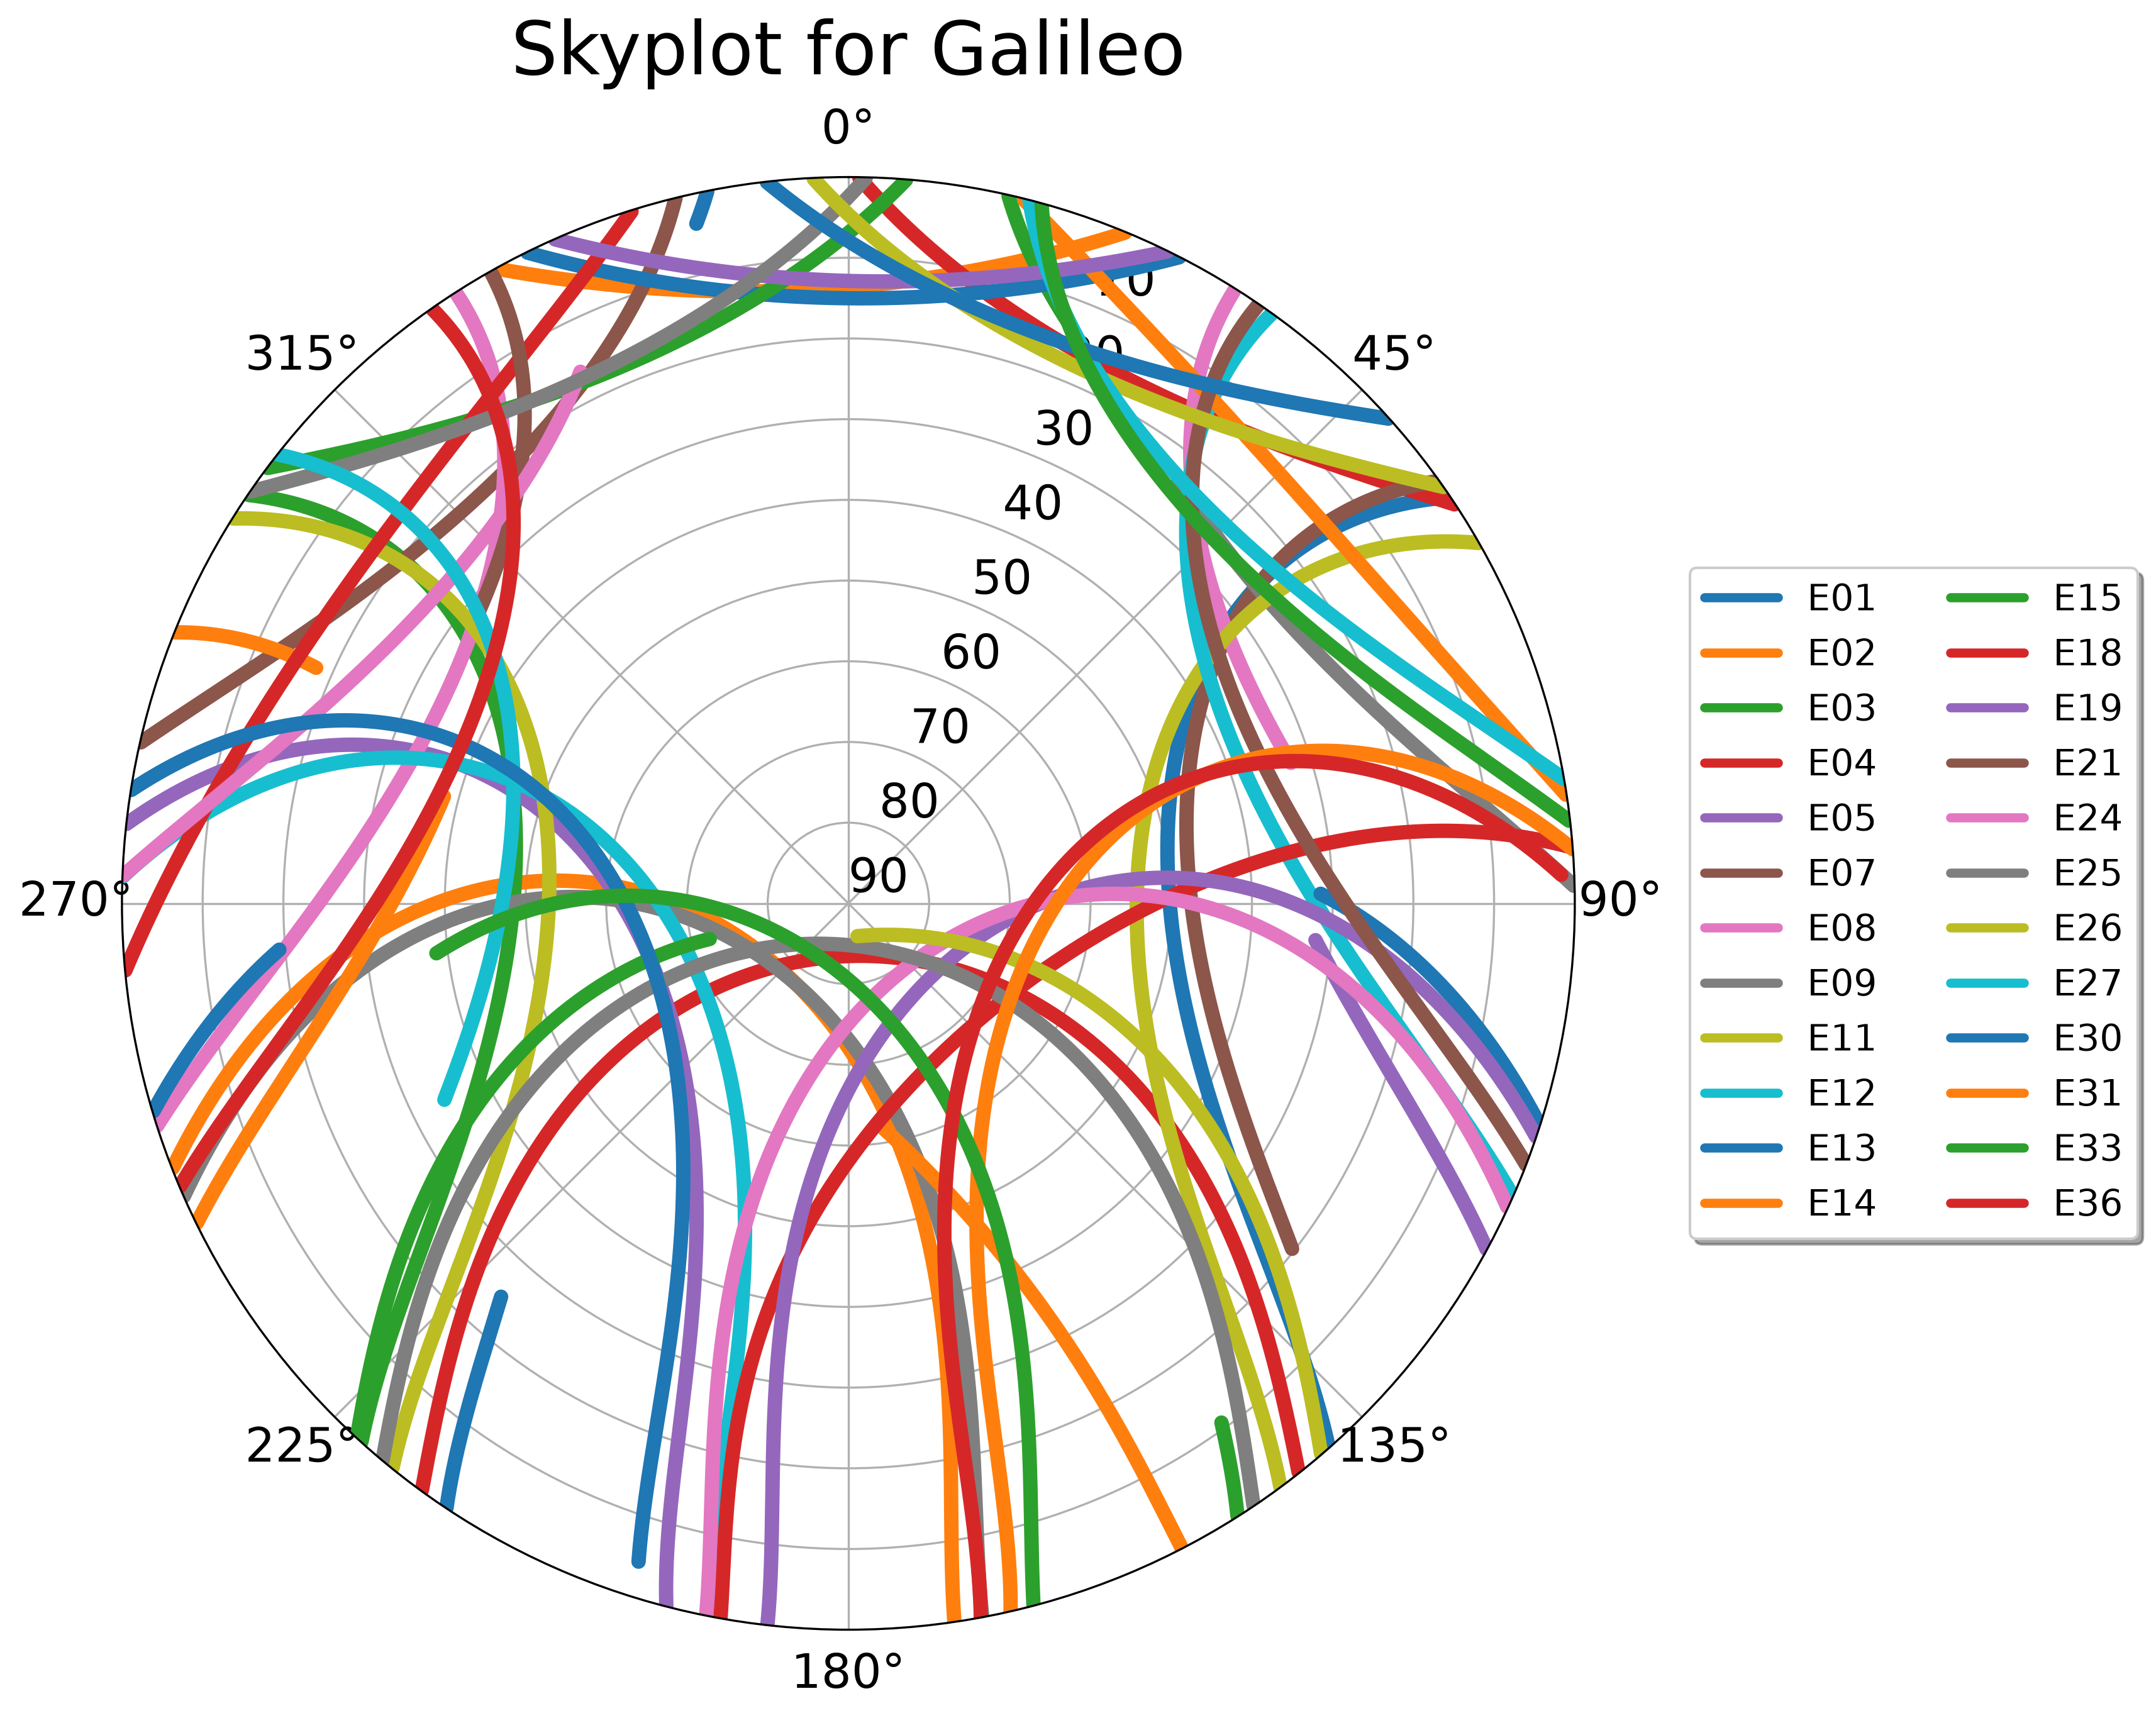

In [ ]:
from io import BytesIO
from IPython.display import Image
import gnssmultipath.plot.make_polarplot as polarplot

# Skyplot basert på de kringkastede efemeridene
angles = converter.compute_satellite_azimut_and_elevation_angle(drop_below_horizon=True)
system_code = 'E'
system_name = 'Galileo'

fig = polarplot.make_skyplot(angles[system_code]['azimuth'], angles[system_code]['elevation'],
                             system_name, None, use_tex=False, save=False, return_fig=True)

image = BytesIO()
fig.savefig(image, format='png', dpi=300, bbox_inches='tight')
Image(data=image.getvalue(), width=600)


In [ ]:
# Samme plot, men med de presise banene fra SP3-fila. Resultatet har samme struktur som for de
# kringkastede efemeridene, og mottakerposisjonen oppgis her fordi den bare trengs til vinklene.
angles_sp3 = precise.compute_satellite_azimut_and_elevation_angle((x_rec, y_rec, z_rec), drop_below_horizon=True)

fig = polarplot.make_skyplot(angles_sp3[system_code]['azimuth'], angles_sp3[system_code]['elevation'],
                             system_name, None, use_tex=False, save=False, return_fig=True)

image = BytesIO()
fig.savefig(image, format='png', dpi=300, bbox_inches='tight')
Image(data=image.getvalue(), width=600)
